## Method One: Holdout Method
- hold out some instances for testing
- common ratios: 70-30, 75-25, 90-10

In [17]:
import pandas as pd
df = pd.read_csv("shirt_sizes_long.csv")
print(df.head())

X = df.drop(["t-shirt size"], axis="columns")
y = df["t-shirt size"]
print(X.head())
print(y.head())

   height(cm)  weight(kg) t-shirt size
0         158          58            M
1         158          59            M
2         158          63            M
3         160          59            M
4         160          60            M
   height(cm)  weight(kg)
0         158          58
1         158          59
2         158          63
3         160          59
4         160          60
0    M
1    M
2    M
3    M
4    M
Name: t-shirt size, dtype: object


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

print(X_train)
print(y_train)
print(len(X_train))
print(len(X_test))

    height(cm)  weight(kg)
4          160          60
16         170          64
1          158          59
15         170          63
11         165          65
10         165          62
5          163          60
3          160          59
13         168          63
8          163          64
0          158          58
7          160          64
17         170          68
9          165          61
4     M
16    L
1     M
15    L
11    L
10    L
5     M
3     M
13    L
8     L
0     M
7     L
17    L
9     L
Name: t-shirt size, dtype: object
14
4


In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(X_train)
print(X_test)

[[0.16666667 0.2       ]
 [1.         0.6       ]
 [0.         0.1       ]
 [1.         0.5       ]
 [0.58333333 0.7       ]
 [0.58333333 0.4       ]
 [0.41666667 0.2       ]
 [0.16666667 0.1       ]
 [0.83333333 0.5       ]
 [0.41666667 0.6       ]
 [0.         0.        ]
 [0.16666667 0.6       ]
 [1.         1.        ]
 [0.58333333 0.3       ]]
[[0.83333333 0.4       ]
 [0.         0.5       ]
 [0.83333333 0.8       ]
 [0.41666667 0.3       ]]


In [20]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(n_neighbors = 3, metric="euclidean")
knn_clf.fit(X_train, y_train)
y_predicted = knn_clf.predict(X_test)
print(y_predicted)

['L' 'M' 'L' 'L']


In [21]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_predicted)
print(acc)

0.75


[[2 0]
 [1 1]]


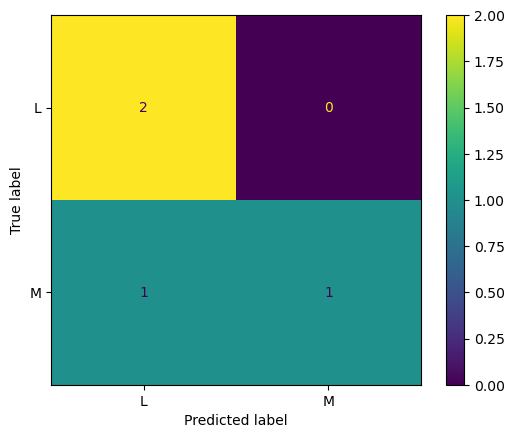

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_predicted)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_clf.classes_)
disp.plot()

tree acc = 0.5, knn acc = 0.75


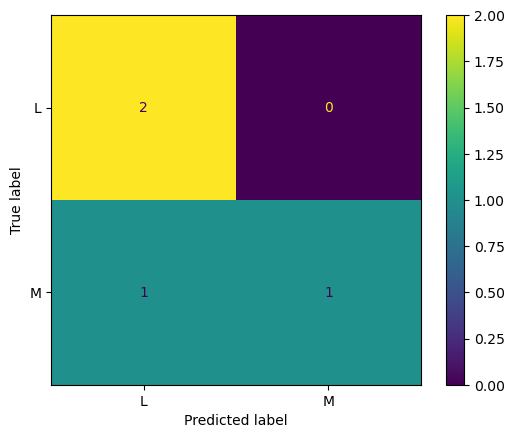

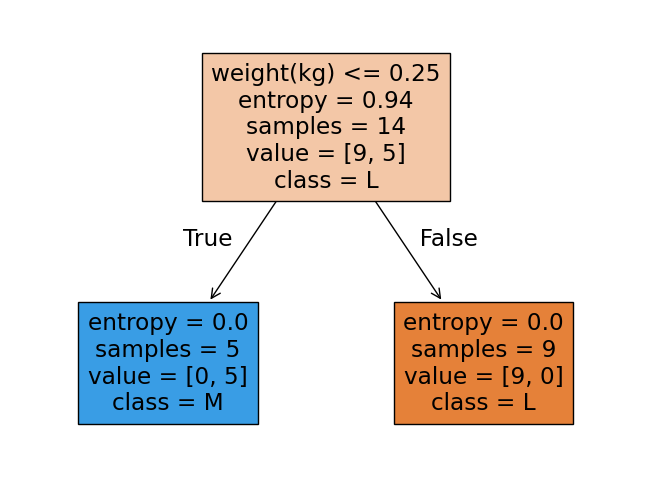

In [23]:
# task: Decision Tree Classifier
# using our X_train, y_train, X_test, y_test
# get the accuracy of the tree and the confusion matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt


tree_clf = DecisionTreeClassifier(criterion="entropy")
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)

tree_acc = accuracy_score(y_test, y_pred_tree)
print(f"tree acc = {tree_acc}, knn acc = {acc}")

tree_cm = confusion_matrix(y_test,y_predicted)
disp = ConfusionMatrixDisplay(confusion_matrix=tree_cm, display_labels=tree_clf.classes_)
disp.plot()

plt.figure(layout="constrained")
plot_tree(tree_clf, feature_names=X.columns, class_names=tree_clf.classes_, filled=True)

plt.show()

## K-Fold Cross Validation

Test with every instance in our dataset exactly once

Basic Alg:Divide our dataset into k folds

    - train on k-1 of those folds
    - test on the other fold
    - Repeat k times

In [24]:
from sklearn.model_selection import cross_val_score, cross_val_predict
import numpy as np 
from sklearn.pipeline import make_pipeline

tree_clf = DecisionTreeClassifier()

knn_clf_3 = make_pipeline(MinMaxScaler(), KNeighborsClassifier(n_neighbors=3, metric="euclidean"))
knn_clf_5 = make_pipeline(MinMaxScaler(), KNeighborsClassifier(n_neighbors=5, metric="euclidean"))
knn_clf_7 = make_pipeline(MinMaxScaler(), KNeighborsClassifier(n_neighbors=7, metric="euclidean"))

models = [("tree_clf", tree_clf), 
          ("knn 3", knn_clf_3),
          ("knn 5", knn_clf_5),
          ("knn 7", knn_clf_7)]

for model in models:
    print(model[0])
    accuracies = cross_val_score(model[1], X, y, cv=5)
    print(accuracies, np.mean(accuracies))

    # slightly better way

    y_predicted = cross_val_predict(model[1], X, y, cv=5)
    acc = accuracy_score(y, y_predicted)
    print(acc)
    print(confusion_matrix(y, y_predicted))



tree_clf
[0.5        0.5        1.         1.         0.66666667] 0.7333333333333333
0.7222222222222222
[[8 3]
 [2 5]]
knn 3
[0.75       0.5        1.         1.         0.66666667] 0.7833333333333333
0.7777777777777778
[[8 3]
 [1 6]]
knn 5
[0.75 1.   1.   1.   1.  ] 0.95
0.9444444444444444
[[10  1]
 [ 0  7]]
knn 7
[0.75       1.         1.         1.         0.66666667] 0.8833333333333334
0.8888888888888888
[[10  1]
 [ 1  6]]
